# Vault Secrets Operator con Secretos Dinámicos

In [ ]:
# Configurar las variables de entorno para conectar con Vault.
# VAULT_ADDR apunta a la IP local de la máquina donde corre Vault en Podman.
# VAULT_TOKEN es el token raíz (solo para desarrollo/demo).
%env VAULT_ADDR=http://192.168.1.41:8200
%env VAULT_TOKEN=root

# Instalación vía Operator HUB

In [ ]:
%%bash
# Consultar los detalles del operador VSO disponible en OperatorHub,
# incluyendo canales de actualización y versiones disponibles.
oc describe packagemanifests \
  -n openshift-marketplace \
  vault-secrets-operator

In [ ]:
%%bash
# Crear la suscripción para instalar VSO desde OperatorHub.
# Se usa el canal "stable" y aprobación manual del plan de instalación.
oc apply -f - <<EOF
apiVersion: operators.coreos.com/v1alpha1
kind: Subscription
metadata:
  name: vault-secrets-operator
  namespace: openshift-operators
spec:
  channel: stable
  name: vault-secrets-operator
  source: certified-operators
  sourceNamespace: openshift-marketplace
  startingCSV: vault-secrets-operator.v1.2.0
  installPlanApproval: Manual
EOF

In [ ]:
# Listar los planes de instalación pendientes de aprobación
! oc get installplans -n openshift-operators

In [ ]:
# Verificar los detalles del plan de instalación antes de aprobarlo
! oc describe installplan install-sq6jt -n openshift-operators

In [ ]:
%%bash
# Aprobar manualmente el plan de instalación para desplegar VSO
oc patch installplan install-sq6jt -n openshift-operators \
  --type merge --patch '{"spec":{"approved":true}}'

In [ ]:
%%bash
# Verificar que el CSV (ClusterServiceVersion) del operador está en estado "Succeeded"
oc get csv -n openshift-operators

In [ ]:
%%bash
# Comprobar que los pods del operador están corriendo correctamente
oc get pods -n openshift-operators

## Instalación vía HELM

In [ ]:
%%bash
# Añadir el repositorio de Helm de HashiCorp y actualizar el índice
helm repo add hashicorp https://helm.releases.hashicorp.com
helm repo update

### Instalación del Vault Secrets Operator (VSO)

Instalamos el Vault Secrets Operator utilizando Helm. Este operador se encargará de gestionar la sincronización de secretos entre Vault y Kubernetes.

**Nota sobre el registro de imágenes:** En esta instalación con Helm se descargan las imágenes desde **Docker Hub** (`docker.io/hashicorp/vault-secrets-operator:1.2.0-ubi`), no desde el registro de Red Hat (`registry.connect.redhat.com`). Se usa Docker Hub porque sus imágenes son manifiestos **multi-arch** que incluyen **arm64** (necesario para Apple Silicon/CRC), no requieren autenticación al registry de Red Hat, y el tag `1.2.0-ubi` solo está disponible en Docker Hub.

Es posible usar imágenes del registro de RedHat para arquitecturas amd64
https://catalog.redhat.com/en/software/containers/hashicorp/vault-secrets-operator-bundle/64ddcd189d40d16b88133fd8?image=6998a5256557715089aa3582#get-this-image
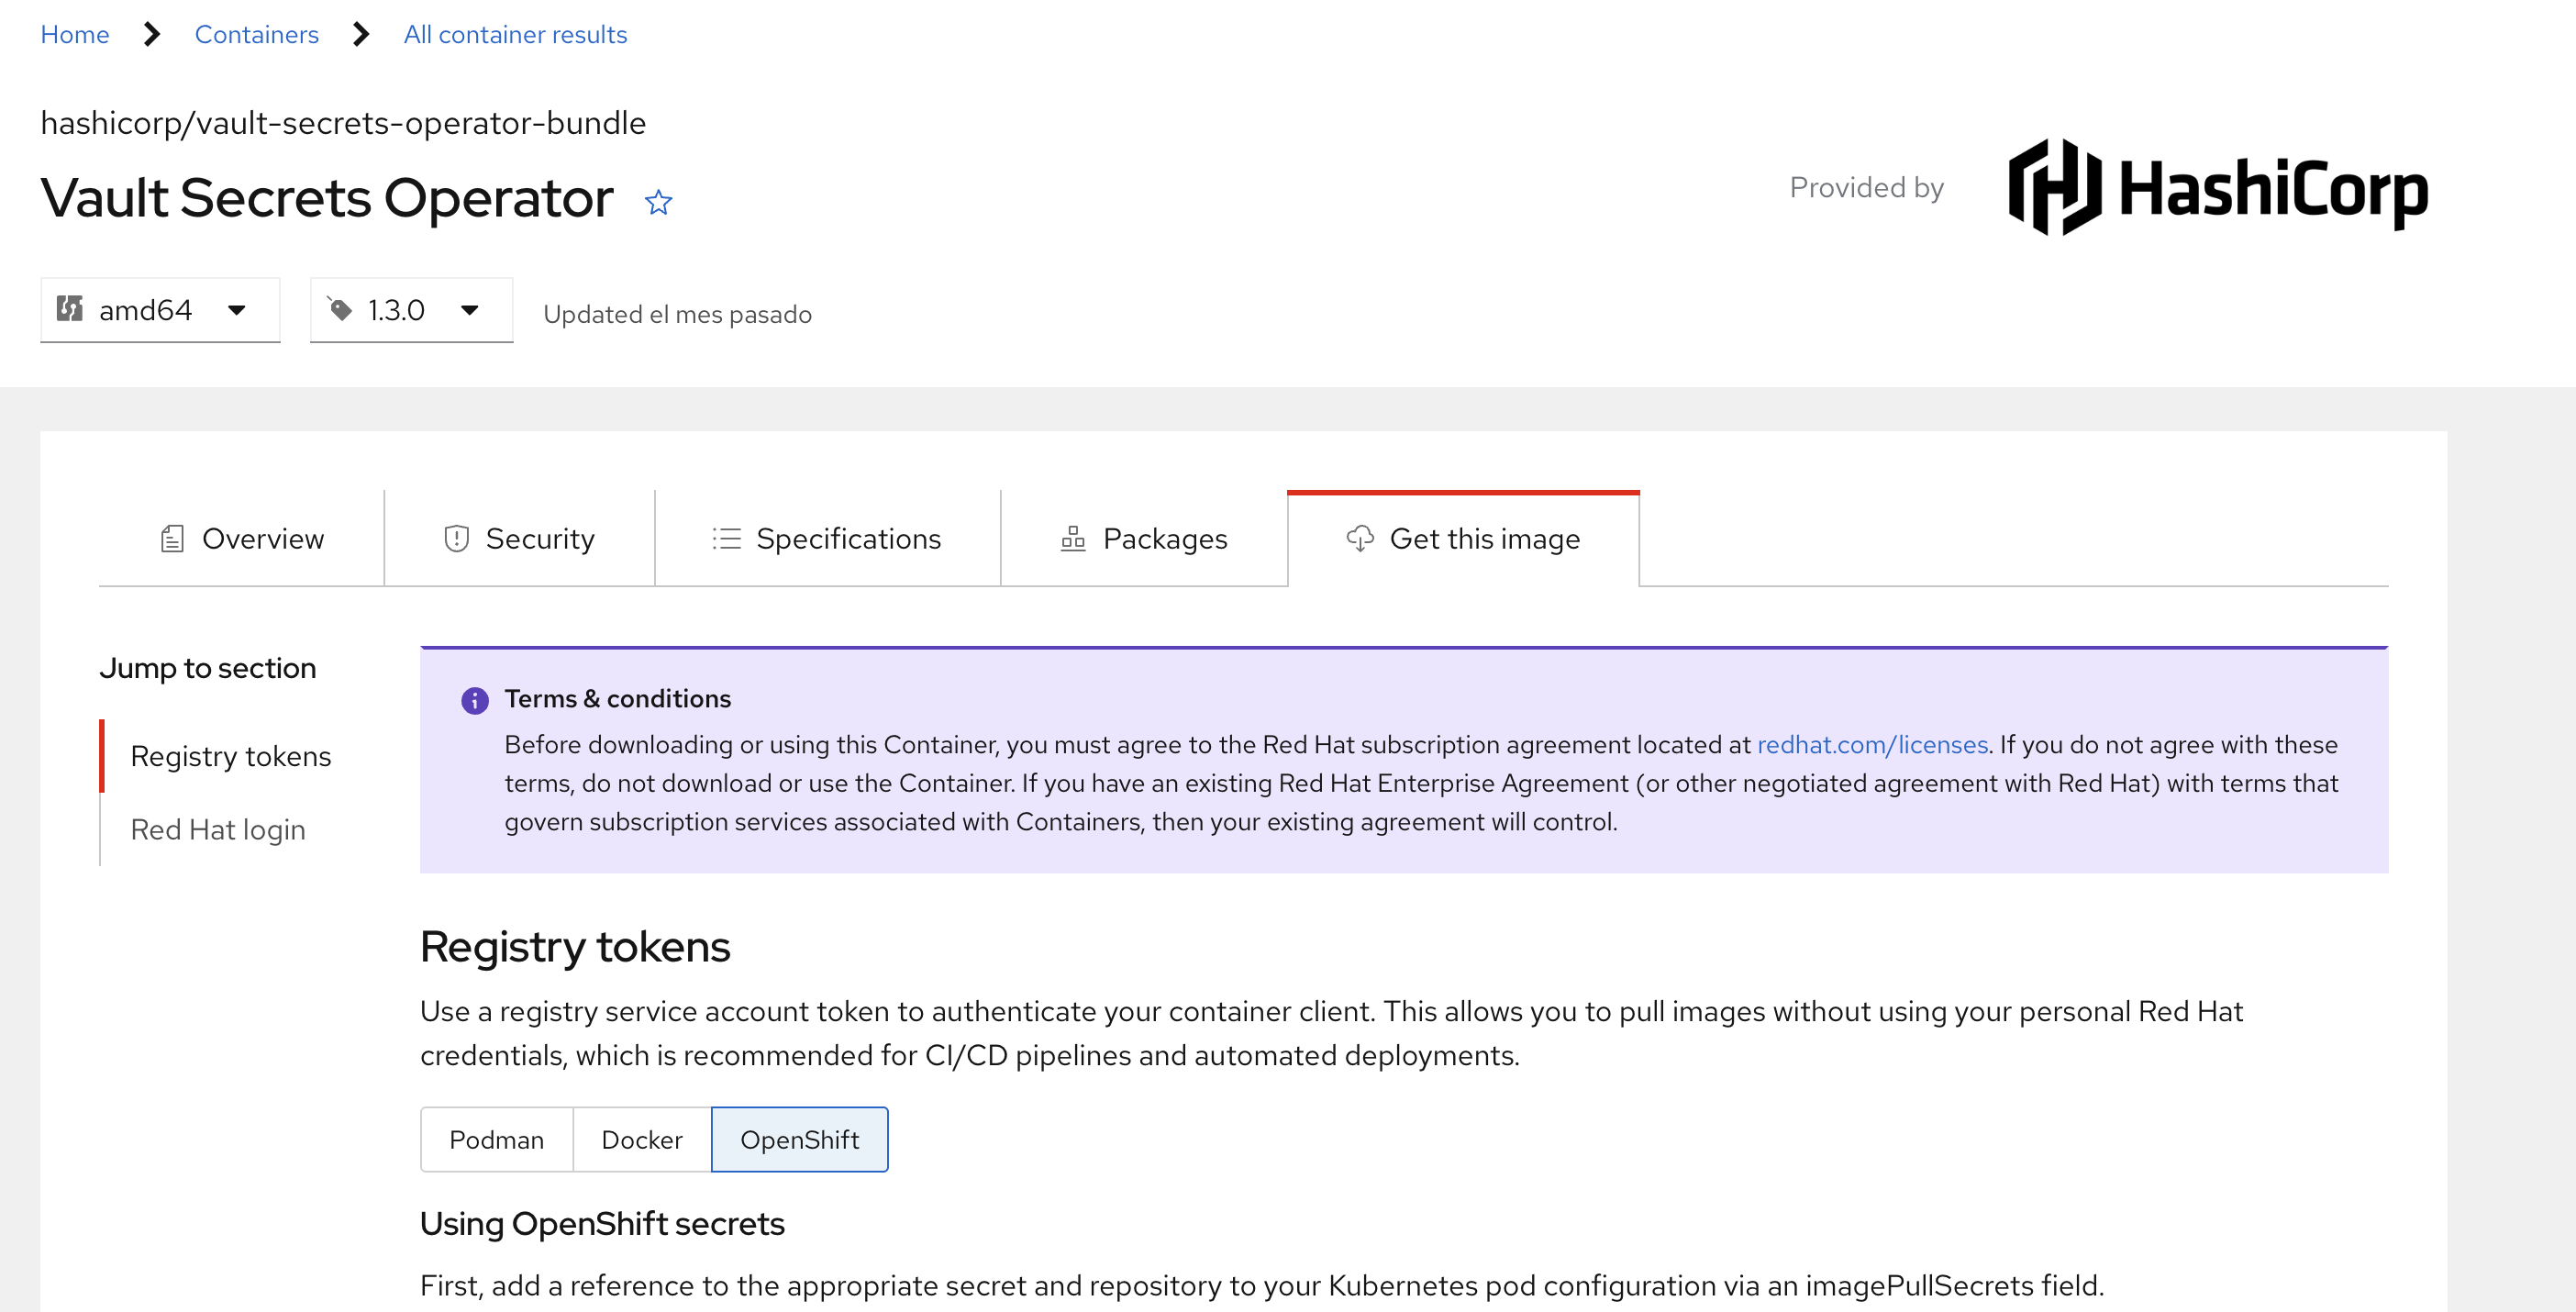

El uso del registro de redhat se fuerza por medio del uso de un values.yaml con la instalación del helm chart. https://developer.hashicorp.com/vault/docs/deploy/kubernetes/vso/openshift#ubi-based-images-certified-by-red-hat

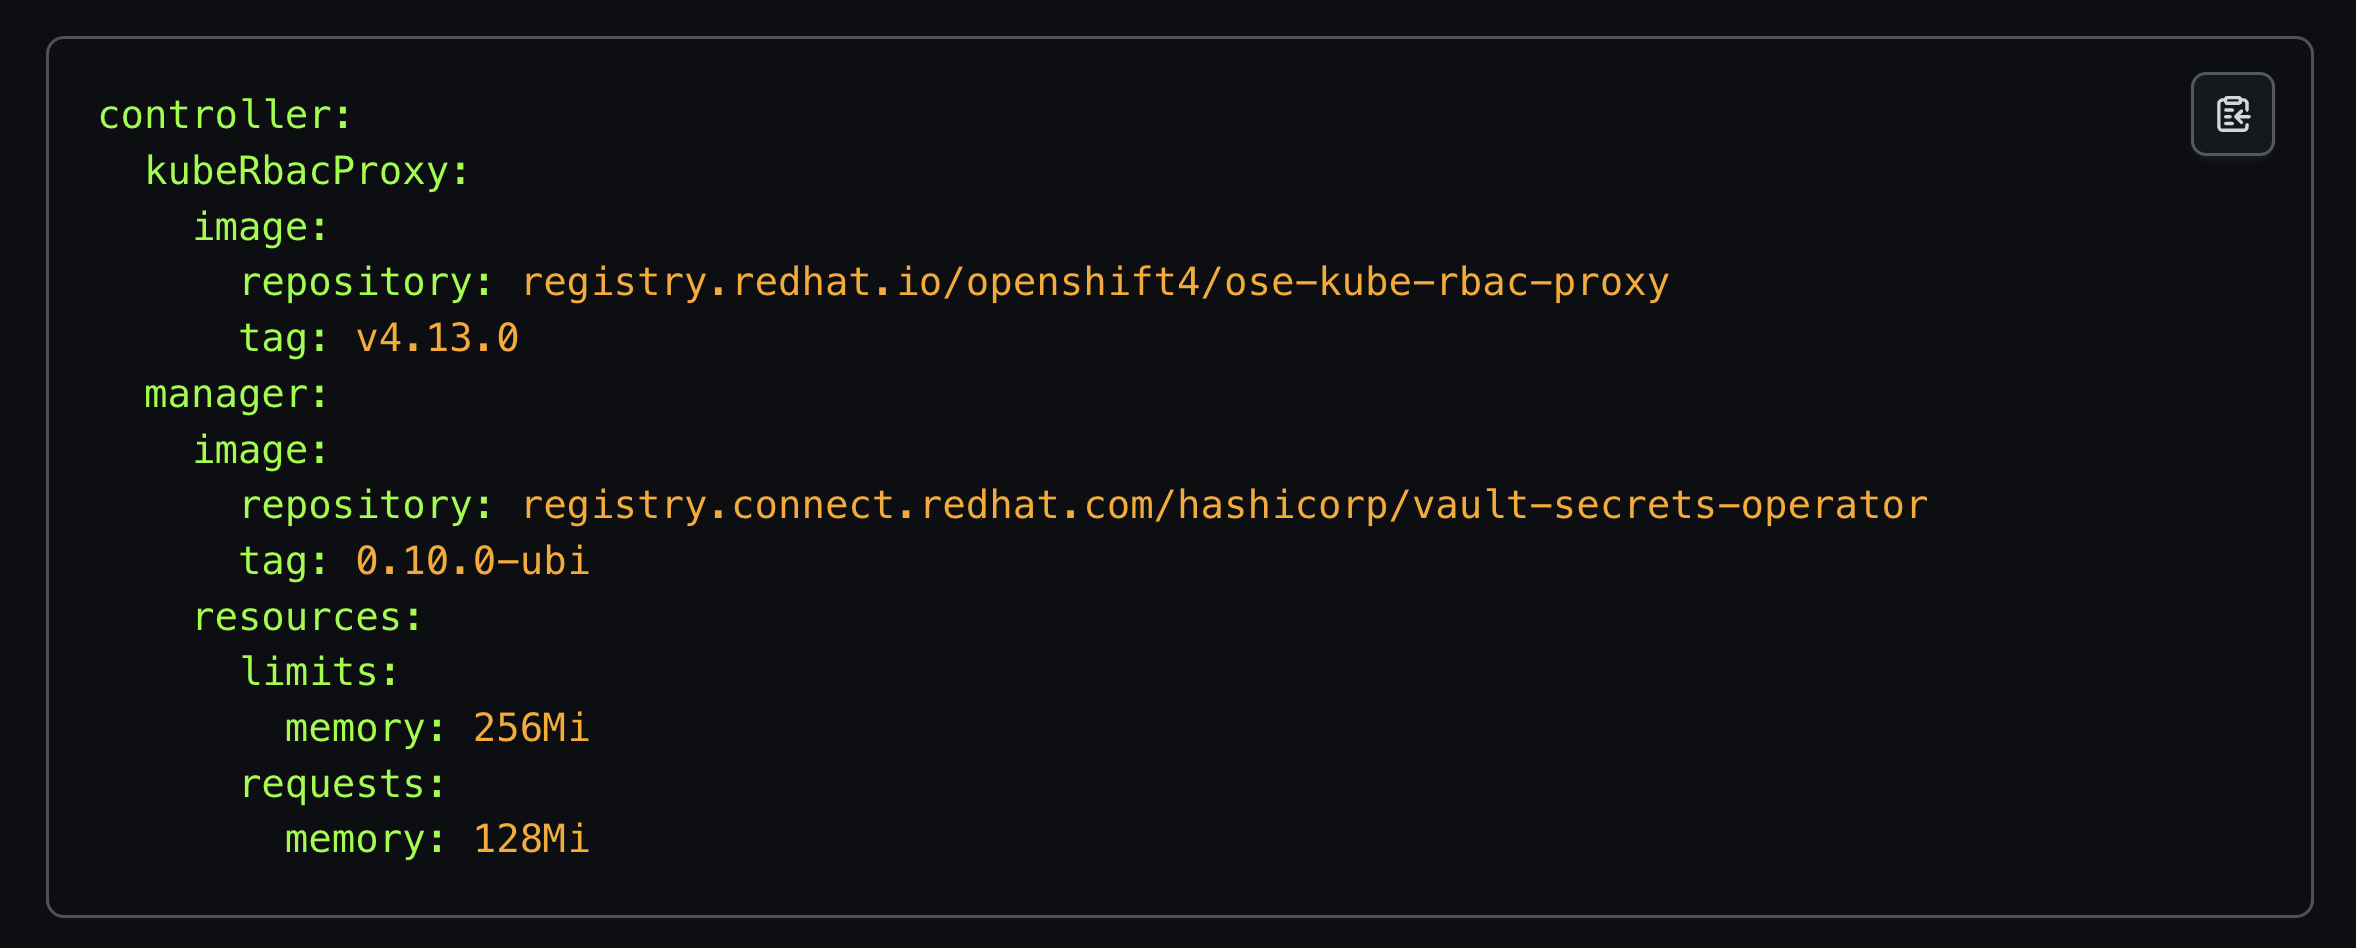

In [ ]:
%%bash
# Limpiar todos los recursos cluster-scoped huérfanos creados por OLM.
# OLM deja ClusterRoles y ClusterRoleBindings al eliminar la suscripción/CSV.
oc get clusterrole,clusterrolebinding \
  --no-headers -o custom-columns='KIND:.kind,NAME:.metadata.name' \
  | awk '/vault|hcpvault/ {print tolower($1) "/" $2}' \
  | xargs -r oc delete --ignore-not-found

# Instalar VSO vía Helm usando imágenes de DockerHub (hashicorp/vault-secrets-operator).
# Las imágenes UBI del manager y kube-rbac-proxy en DockerHub/GCR son manifiestos
# multi-arch que incluyen arm64 — no requiere autenticación a Red Hat registry.
# --no-hooks evita los Jobs de pre-install/pre-delete para que 'helm uninstall'
# no se bloquee si la imagen no puede descargarse.
helm install vault-secrets-operator hashicorp/vault-secrets-operator \
  --version 1.2.0 \
  --create-namespace \
  --namespace vault-secrets-operator \
  --no-hooks \
  --set controller.manager.image.repository=hashicorp/vault-secrets-operator \
  --set controller.manager.image.tag=1.2.0-ubi \
  --set controller.manager.resources.requests.memory=128Mi \
  --set controller.manager.resources.limits.memory=256Mi

echo "Esperando a que el pod de VSO esté listo..."
oc rollout status deployment/vault-secrets-operator-controller-manager \
  -n vault-secrets-operator --timeout=180s

In [ ]:
# Verificar que los pods de VSO están corriendo en su namespace
! kubectl get pods -n vault-secrets-operator

## Configurar JWT Auth Method

In [ ]:
%%bash
# Permitir el acceso no autenticado a los endpoints de descubrimiento OIDC
# (/.well-known/openid-configuration y /openid/v1/jwks).
# Estos endpoints solo exponen claves públicas criptográficas, por lo que
# el riesgo de seguridad es mínimo. Vault necesita acceder a estos endpoints
# para obtener las claves públicas sin autenticarse contra el API server.
oc create clusterrolebinding oidc-reviewer  \
   --clusterrole=system:service-account-issuer-discovery \
   --group=system:unauthenticated

In [ ]:
%%bash
# Obtener el emisor (issuer) de tokens del clúster desde el endpoint OIDC.
# En OpenShift, típicamente es "https://kubernetes.default.svc".
ISSUER="$(kubectl get --raw /.well-known/openid-configuration | jq -r '.issuer')"
echo $ISSUER

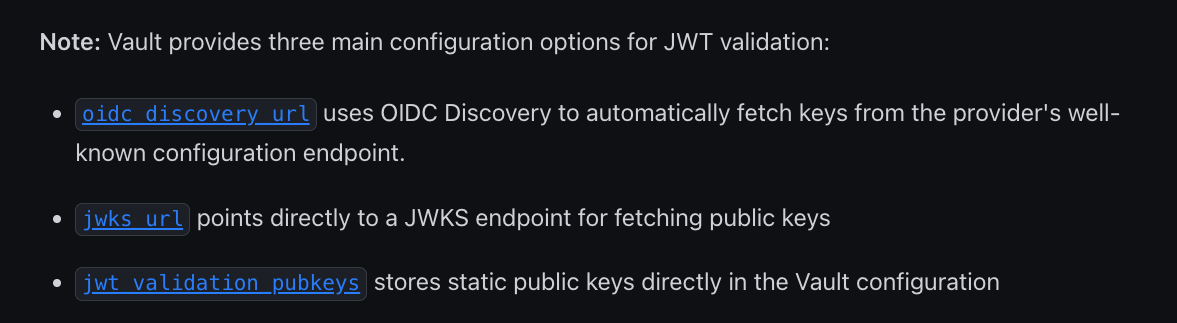

## Obtener clave pública JWKS

In [ ]:
%%bash
# Extraer la primera clave pública JWKS del clúster y convertirla de formato JWK a PEM.
# Se usa el módulo crypto de Node.js para la conversión (sin dependencias externas).
oc get --raw \
  "$(oc get --raw /.well-known/openid-configuration | jq -r '.jwks_uri' | sed 's|https://[^/]*||')" \
| jq '.keys[0]' \
| node -e "const c=require('crypto');let d='';process.stdin.on('data',x=>d+=x).on('end',()=>console.log(c.createPublicKey({key:JSON.parse(d),format:'jwk'}).export({type:'spki',format:'pem'})))"

## Habilitar autenticación JWT

In [ ]:
# Habilitar el método de autenticación JWT en Vault (mount por defecto: jwt/)
! vault auth enable jwt

In [ ]:
%%bash
# Obtener TODAS las claves de firma actuales del JWKS del clúster y enviarlas a Vault.
# Se usa la API HTTP (no el CLI) porque 'vault write' solo acepta una clave pública.
# Es necesario re-ejecutar esta celda cada vez que se recrea el clúster
# (las claves cambian en cada reinicio de CRC).
JWKS_PATH=$(kubectl get --raw /.well-known/openid-configuration | jq -r '.jwks_uri' | sed 's|https://[^/]*||')

# Convertir todas las claves JWK a formato PEM usando el módulo crypto de Node.js
PUBKEYS_JSON=$(kubectl get --raw "$JWKS_PATH" | jq '.keys' \
  | node -e "
      const c = require('crypto');
      let d = '';
      process.stdin.on('data', x => d += x).on('end', () => {
        const pems = JSON.parse(d).map(k =>
          c.createPublicKey({key: k, format: 'jwk'}).export({type: 'spki', format: 'pem'})
        );
        console.log(JSON.stringify(pems));
      });
    ")

# Enviar las claves públicas a Vault mediante la API HTTP
curl -sf -X PUT "${VAULT_ADDR}/v1/auth/jwt/config" \
  -H "X-Vault-Token: ${VAULT_TOKEN}" \
  -d "{\"jwt_validation_pubkeys\": ${PUBKEYS_JSON}}" \
  && echo "OK: Vault actualizado con $(kubectl get --raw "$JWKS_PATH" | jq '.keys | length') claves de firma de OCP" \
  || echo "FALLO"

In [ ]:
%%bash
# Crear un rol JWT en Vault que mapea la cuenta de servicio de Kubernetes
# a una política de Vault. Solo se aceptan tokens con la audiencia correcta
# y del service account "default" en el namespace "default".
vault write auth/jwt/role/my-role \
   role_type="jwt" \
   bound_audiences="https://kubernetes.default.svc" \
   user_claim="sub" \
   bound_subject="system:serviceaccount:default:default" \
   policies="devk8s" \
   ttl="1h"

### Política de acceso

In [ ]:
%%bash
# Crear la política de Vault que permite leer las credenciales estáticas de AWS.
# Esta política será asignada al rol JWT "my-role".
vault policy write devk8s - <<EOF
path "aws/static-creds/app-test" {
  capabilities = ["read"]
}
EOF

### Configurar la conexión de VSO con Vault (VaultConnection)

Creamos un recurso `VaultConnection` que define cómo el operador debe conectarse a la instancia de Vault. En este caso, apuntamos a la dirección de Vault configurada en las variables de entorno.

In [ ]:
%%bash
# Crear el recurso VaultConnection que indica a VSO cómo conectarse a Vault.
# Usa la dirección configurada en VAULT_ADDR como destino.
cat > vso_crd.yaml <<EOF
---
apiVersion: secrets.hashicorp.com/v1beta1
kind: VaultConnection
metadata:
  namespace: vault-secrets-operator
  name: example
spec:
  address: ${VAULT_ADDR}

EOF

kubectl apply -f vso_crd.yaml

In [ ]:
# Verificar el estado del recurso VaultConnection
! kubectl describe VaultConnection example -n vault-secrets-operator

### Configurar la autenticación de VSO (VaultAuth)

Creamos un recurso `VaultAuth` que especifica el método de autenticación que VSO utilizará para autenticarse con Vault. Usamos el método `jwt` y el rol `my-role` que configuramos anteriormente. Esto permite que VSO utilice la cuenta de servicio de Kubernetes para obtener un token de Vault.

In [ ]:
%%bash
# Crear el recurso VaultAuth que configura la autenticación JWT con Vault.
# allowedNamespaces: ["*"] permite que cualquier namespace use este auth.
# Referencia la VaultConnection "example" y el método JWT con el rol "my-role".
cat > vaultauth_crd.yaml <<EOF
---
apiVersion: secrets.hashicorp.com/v1beta1
kind: VaultAuth
metadata:
  namespace: vault-secrets-operator
  name: example
spec:
  vaultConnectionRef: example
  allowedNamespaces: ["*"]
  method: jwt
  mount: jwt

  jwt:
    role: my-role
    serviceAccount: default
    audiences: ["https://kubernetes.default.svc"]

EOF
kubectl apply -f vaultauth_crd.yaml

In [ ]:
# Verificar el estado del recurso VaultAuth
! kubectl describe VaultAuth example -n vault-secrets-operator

In [ ]:
%%bash
# Crear el recurso VaultDynamicSecret para sincronizar las credenciales
# estáticas de AWS desde Vault hacia un Secret de Kubernetes.
# VSO se encargará de renovar el secreto automáticamente según el TTL.
cat > dynamic_secret_aws.yaml <<EOF
---
apiVersion: secrets.hashicorp.com/v1beta1
kind: VaultDynamicSecret
metadata:
  namespace: default
  name: aws-secret
spec:
  vaultAuthRef: vault-secrets-operator/example
  mount: aws
  path: static-creds/app-test
  destination:
    create: true
    name: aws-secret
EOF

kubectl apply -f dynamic_secret_aws.yaml

In [ ]:
# Verificar el estado de sincronización del VaultDynamicSecret
! kubectl describe VaultDynamicSecret aws-secret -n default

In [ ]:
%%bash
# Esperar a que VSO cree el Secret y mostrar su contenido completo (codificado en base64)
sleep 5
kubectl get secret aws-secret -n default -o yaml

In [ ]:
%%bash
# Decodificar y mostrar los valores del secreto AWS sincronizado por VSO
echo "expires_at_seconds: $(kubectl get secret aws-secret -n default -o json | jq -r .data.expiration | base64 -d)"
echo "ACCESS_KEY: $(kubectl get secret aws-secret -n default -o json | jq -r .data.access_key | base64 -d)"
echo "SECRET_KEY: $(kubectl get secret aws-secret -n default -o json | jq -r .data.secret_key | base64 -d)"

In [ ]:
%%bash
# Desplegar una aplicación NGINX (UBI9) que muestra los valores de aws-secret en una web.
# El contenedor genera index.html a partir de las variables de entorno inyectadas
# desde el Secret, y luego inicia NGINX. Se crean también el Service y la Route.
cat > secret-viewer-1.yaml <<'EOF'
---
apiVersion: apps/v1
kind: Deployment
metadata:
  name: secret-viewer-1
  namespace: default
spec:
  replicas: 1
  selector:
    matchLabels:
      app: secret-viewer-1
  template:
    metadata:
      labels:
        app: secret-viewer-1
    spec:
      containers:
      - name: nginx
        image: registry.redhat.io/ubi9/nginx-120
        ports:
        - containerPort: 8080
        envFrom:
        - secretRef:
            name: aws-secret
        command: ["/bin/bash", "-c"]
        args:
        - |
          cat > /opt/app-root/src/index.html <<HTMLEOF
          <!DOCTYPE html>
          <html>
          <head>
            <title>AWS Dynamic Secret</title>
            <style>
              body { font-family: sans-serif; margin: 40px; background: #f5f5f5; }
              h1 { color: #326CE5; }
              table { border-collapse: collapse; margin-top: 20px; }
              th, td { border: 1px solid #ccc; padding: 10px 16px; text-align: left; }
              th { background: #326CE5; color: white; }
              td { background: white; font-family: monospace; }
            </style>
          </head>
          <body>
            <h1>AWS Dynamic Secret (aws-secret)</h1>
            <p>Managed by Vault Secrets Operator</p>
            <table>
              <tr><th>Key</th><th>Value</th></tr>
              <tr><td>access_key</td><td>${access_key}</td></tr>
              <tr><td>secret_key</td><td>${secret_key}</td></tr>
              <tr><td>expiration</td><td>${expiration}</td></tr>
            </table>
          </body>
          </html>
          HTMLEOF
          exec /usr/libexec/s2i/run
---
apiVersion: v1
kind: Service
metadata:
  name: secret-viewer-1
  namespace: default
spec:
  selector:
    app: secret-viewer-1
  ports:
  - port: 8080
    targetPort: 8080
---
apiVersion: route.openshift.io/v1
kind: Route
metadata:
  name: secret-viewer-1
  namespace: default
spec:
  to:
    kind: Service
    name: secret-viewer-1
  port:
    targetPort: 8080
EOF

oc apply -f secret-viewer-1.yaml

In [ ]:
# Comprobar que el pod de la aplicación NGINX está corriendo
! oc get pods -l app=secret-viewer-1 -n default

In [ ]:
%%bash
# Obtener la URL de la Route y verificar que la página muestra los valores del secreto
ROUTE_URL=$(oc get route secret-viewer-1 -n default -o jsonpath='{.spec.host}')
echo "Route: http://${ROUTE_URL}"
echo "---"
curl -s "http://${ROUTE_URL}"

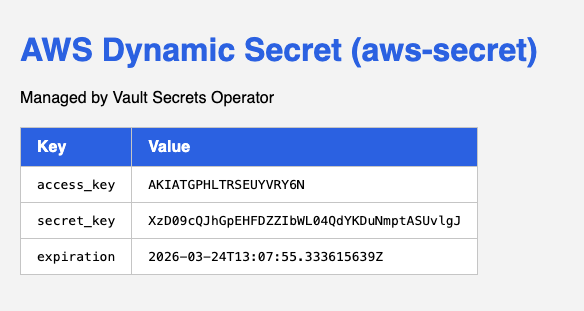

## JWT con validación por endpoint público (jwks_url)

En lugar de copiar las claves públicas estáticamente, configuramos Vault para que las lea directamente desde el endpoint JWKS de OpenShift. Vault validará los tokens JWT consultando ese endpoint en tiempo real, de forma que las rotaciones de certificados son transparentes.

In [ ]:
%%bash
# El kubeconfig de CRC usa insecure-skip-tls-verify (no tiene el CA embebido).
# Extraemos el certificado CA de la cadena TLS que presenta el API server.
# El 2º certificado en la cadena es el CA firmante (kube-apiserver-lb-signer).
# Ref: https://developer.hashicorp.com/validated-patterns/vault/vault-pki-with-vso-and-openshift
openssl s_client -showcerts -connect api.crc.testing:6443 </dev/null 2>/dev/null | \
  awk '/-----BEGIN CERTIFICATE-----/{p++} p==2' | \
  openssl x509 -outform PEM > openshift-ca.pem

echo "Sujeto del CA:"
openssl x509 -noout -subject -in openshift-ca.pem

In [ ]:
%%bash
# Dentro del contenedor Podman de Vault, api.crc.testing resuelve a 127.0.0.1
# (que es él mismo, no el host). Añadimos una entrada en /etc/hosts apuntando
# al gateway del host para que Vault pueda alcanzar el API server de CRC.
HOST_IP=$(podman exec vault-enterprise sh -c 'getent hosts host.containers.internal | awk "{print \$1}"')
podman exec vault-enterprise sh -c "grep -q api.crc.testing /etc/hosts || echo '${HOST_IP} api.crc.testing' >> /etc/hosts"
echo "Entrada en /etc/hosts del contenedor Vault: api.crc.testing -> ${HOST_IP}"

# Construir la URL del JWKS usando el hostname api.crc.testing
JWKS_PATH=$(oc get --raw /.well-known/openid-configuration | jq -r '.jwks_uri' | sed 's|https://[^/]*||')
JWKS_URL="https://api.crc.testing:6443${JWKS_PATH}"
echo "JWKS_URL: $JWKS_URL"

# Habilitar un segundo mount JWT para la validación por endpoint público
vault auth enable -path=jwt-pub-end jwt 2>/dev/null || true

# Configurar el mount con la URL del JWKS y el certificado CA para verificar TLS
vault write auth/jwt-pub-end/config \
  jwks_url="$JWKS_URL" \
  jwks_ca_pem=@openshift-ca.pem

In [ ]:
%%bash
# Crear el rol JWT en el mount jwt-pub-end con las mismas restricciones
# que el rol anterior: audiencia, service account y política de acceso.
vault write auth/jwt-pub-end/role/my-role \
   role_type="jwt" \
   bound_audiences="https://kubernetes.default.svc" \
   user_claim="sub" \
   bound_subject="system:serviceaccount:default:default" \
   policies="devk8s" \
   ttl="1h"

## CRDs de VaultAuth y VaultDynamicSecret (con jwt-pub-end)

Creamos una segunda configuración de autenticación que usa el mount `jwt-pub-end` (validación por endpoint público) y un segundo `VaultDynamicSecret` para sincronizar el secreto `aws-secret2`.

In [ ]:
%%bash
# Crear un segundo recurso VaultAuth que usa el mount jwt-pub-end
# en lugar de jwt. Referencia la misma VaultConnection "example".
cat > vaultauth_crd2.yaml <<EOF
---
apiVersion: secrets.hashicorp.com/v1beta1
kind: VaultAuth
metadata:
  namespace: vault-secrets-operator
  name: example2
spec:
  vaultConnectionRef: example
  allowedNamespaces: ["*"]
  method: jwt
  mount: jwt-pub-end

  jwt:
    role: my-role
    serviceAccount: default
    audiences: ["https://kubernetes.default.svc"]

EOF
kubectl apply -f vaultauth_crd2.yaml

In [ ]:
%%bash
# Crear un segundo VaultDynamicSecret que sincroniza las mismas credenciales AWS
# pero usando la autenticación por endpoint público (example2 / jwt-pub-end).
cat > dynamic_secret_aws2.yaml <<EOF
---
apiVersion: secrets.hashicorp.com/v1beta1
kind: VaultDynamicSecret
metadata:
  namespace: default
  name: aws-secret2
spec:
  vaultAuthRef: vault-secrets-operator/example2
  mount: aws
  path: static-creds/app-test
  destination:
    create: true
    name: aws-secret2
EOF

kubectl apply -f dynamic_secret_aws2.yaml

In [ ]:
# Verificar el estado de sincronización del VaultDynamicSecret aws-secret2
! kubectl describe VaultDynamicSecret aws-secret2 -n default

In [ ]:
%%bash
# Decodificar y mostrar los valores del secreto AWS sincronizado por jwt-pub-end
echo "expires_at_seconds: $(kubectl get secret aws-secret2 -n default -o json | jq -r .data.expiration | base64 -d)"
echo "ACCESS_KEY: $(kubectl get secret aws-secret2 -n default -o json | jq -r .data.access_key | base64 -d)"
echo "SECRET_KEY: $(kubectl get secret aws-secret2 -n default -o json | jq -r .data.secret_key | base64 -d)"

In [ ]:
%%bash
# Deploy NGINX UBI9 that displays aws-secret2 values on a web page.
# The container generates index.html from env vars at startup, then runs nginx.
cat > secret-viewer.yaml <<'EOF'
---
apiVersion: apps/v1
kind: Deployment
metadata:
  name: secret-viewer2
  namespace: default
spec:
  replicas: 1
  selector:
    matchLabels:
      app: secret-viewer2
  template:
    metadata:
      labels:
        app: secret-viewer2
    spec:
      containers:
      - name: nginx
        image: registry.redhat.io/ubi9/nginx-120
        ports:
        - containerPort: 8080
        envFrom:
        - secretRef:
            name: aws-secret2
        command: ["/bin/bash", "-c"]
        args:
        - |
          cat > /opt/app-root/src/index.html <<HTMLEOF
          <!DOCTYPE html>
          <html>
          <head>
            <title>AWS Dynamic Secret</title>
            <style>
              body { font-family: sans-serif; margin: 40px; background: #f5f5f5; }
              h1 { color: #326CE5; }
              table { border-collapse: collapse; margin-top: 20px; }
              th, td { border: 1px solid #ccc; padding: 10px 16px; text-align: left; }
              th { background: #326CE5; color: white; }
              td { background: white; font-family: monospace; }
            </style>
          </head>
          <body>
            <h1>AWS Dynamic Secret (aws-secret2)</h1>
            <p>Managed by Vault Secrets Operator</p>
            <table>
              <tr><th>Key</th><th>Value</th></tr>
              <tr><td>access_key</td><td>${access_key}</td></tr>
              <tr><td>secret_key</td><td>${secret_key}</td></tr>
              <tr><td>expiration</td><td>${expiration}</td></tr>
            </table>
          </body>
          </html>
          HTMLEOF
          exec /usr/libexec/s2i/run
---
apiVersion: v1
kind: Service
metadata:
  name: secret-viewer2
  namespace: default
spec:
  selector:
    app: secret-viewer2
  ports:
  - port: 8080
    targetPort: 8080
---
apiVersion: route.openshift.io/v1
kind: Route
metadata:
  name: secret-viewer2
  namespace: default
spec:
  to:
    kind: Service
    name: secret-viewer2
  port:
    targetPort: 8080
EOF

oc apply -f secret-viewer.yaml

In [ ]:
! oc get pods -l app=secret-viewer -n default

In [ ]:
%%bash
ROUTE_URL=$(oc get route secret-viewer -n default -o jsonpath='{.spec.host}')
echo "Route: http://${ROUTE_URL}"
echo "---"
curl -s "http://${ROUTE_URL}"

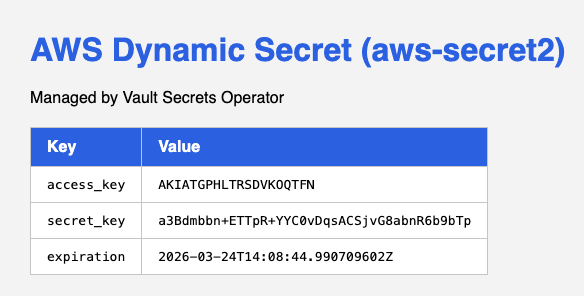